Описательная статистика:
1. Рассчитайте сводную статистику (среднее значение, медиана, режим,
диапазон) для числовых полей.
2. Анализируйте категориальные поля, такие как качество, стадия, источник и
продукт.

датасет Spend

In [1]:
import pandas as pd

spend_df = pd.read_excel("Spend_f_clean.xlsx")

display(spend_df.head())

spend_df.info()


,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN
3,2023-07-03,Google Ads,NaN,0,0.00,0,NaN,NaN
4,2023-07-03,CRM,NaN,0,0.00,0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19862 entries, 0 to 19861
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         19862 non-null  datetime64[ns]
 1   Source       19862 non-null  object        
 2   Campaign     14785 non-null  object        
 3   Impressions  19862 non-null  int64         
 4   Spend        19862 non-null  float64       
 5   Clicks       19862 non-null  int64         
 6   AdGroup      13951 non-null  object        
 7   Ad           13951 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 1.2+ MB


In [2]:

# 1️⃣ Список числовых столбцов
num_cols = ["Impressions", "Spend", "Clicks"]

# 2️⃣ Рассчёт показателей
desc_stats = pd.DataFrame({
    "mean": spend_df[num_cols].mean(),
    "median": spend_df[num_cols].median(),
    "mode": spend_df[num_cols].mode().iloc[0],   # мода может быть несколько — берём первую
    "min": spend_df[num_cols].min(),
    "max": spend_df[num_cols].max(),
})

# 3️⃣ Добавим диапазон (max - min)
desc_stats["range"] = desc_stats["max"] - desc_stats["min"]

display(desc_stats)


,mean,median,mode,min,max,range
Impressions,2571.695197,82.00,0.0,0.0,431445.0,431445.0
Spend,7.528117,0.74,0.0,0.0,774.0,774.0
Clicks,25.095912,2.00,0.0,0.0,2415.0,2415.0


In [3]:
cat_cols = ["Source", "Campaign", "AdGroup", "Ad"]

for col in cat_cols:
    print(f"\n📊 {col}")
    print("Уникальных значений:", spend_df[col].nunique())
    print(spend_df[col].value_counts(dropna=False).head(10))



📊 Source
Уникальных значений: 14
Source
Facebook Ads      9569
Tiktok Ads        2985
Youtube Ads       1784
Google Ads        1266
Telegram posts     836
Webinar            766
Bloggers           632
SMM                571
Organic            514
CRM                355
Name: count, dtype: int64

📊 Campaign
Уникальных значений: 51
Campaign
NaN                          5077
12.07.2023wide_DE            2073
02.07.23wide_DE              1685
04.07.23recentlymoved_DE     1398
youtube_shorts_DE            1223
07.07.23LAL_DE               1181
03.07.23women                1171
12.09.23interests_Uxui_DE    1143
15.07.23b_DE                  529
24.09.23retargeting_DE        504
Name: count, dtype: int64

📊 AdGroup
Уникальных значений: 24
AdGroup
NaN                            5911
wide                           5451
recentlymoved                  1442
women                          1274
LAL1                           1220
Com_august                     1073
interest_work_WebDev            7

<Axes: title={'center': 'Распределение по Source'}, xlabel='Source'>

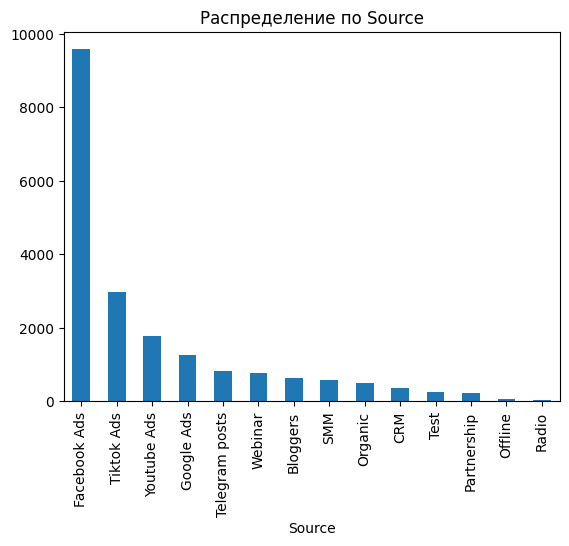

In [4]:
spend_df["Source"].value_counts().plot(kind="bar", title="Распределение по Source")


датасет Contacts

In [5]:
contacts_df = pd.read_excel("Contacts_f_clean.xlsx")

display(contacts_df.head())

contacts_df.info()

,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00
3,5805028000000907006,Bob Brown,2023-07-03 05:44:00,2023-12-29 15:20:00
4,5805028000000939010,Nina Scott,2023-07-04 10:11:00,2024-04-16 16:14:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  18548 non-null  int64         
 1   Contact Owner Name  18548 non-null  object        
 2   Created Time        18548 non-null  datetime64[ns]
 3   Modified Time       18548 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 579.8+ KB


In [28]:
print("Всего строк:", len(contacts_df))
print("Уникальных Id:", contacts_df["Id"].nunique())
print("Дубликатов Id:", len(contacts_df) - contacts_df["Id"].nunique())
print("Пустых значений Id:", contacts_df["Id"].isna().sum())


Всего строк: 18548
Уникальных Id: 18548
Дубликатов Id: 0
Пустых значений Id: 0


In [7]:
# Проверим наличие пропусков
print("Пропусков в Contact Owner Name:", contacts_df["Contact Owner Name"].isna().sum())

# Уникальные значения
print("Уникальных владельцев:", contacts_df["Contact Owner Name"].nunique())

# Частота встречаемости
owner_counts = contacts_df["Contact Owner Name"].value_counts(dropna=False)

# Добавим процентную долю
owner_percent = (owner_counts / len(contacts_df) * 100).round(2)

# Объединим всё в одну таблицу
contact_owner_stats = pd.DataFrame({
    "Количество": owner_counts,
    "Доля, %": owner_percent
})

display(contact_owner_stats.head(10))


Пропусков в Contact Owner Name: 0
Уникальных владельцев: 28


,Количество,"Доля, %"
Contact Owner Name,,
Charlie Davis,2018,10.88
Ulysses Adams,1816,9.79
Julia Nelson,1769,9.54
Paula Underwood,1487,8.02
Quincy Vincent,1416,7.63
Nina Scott,1150,6.20
Ben Hall,1038,5.60
Victor Barnes,967,5.21
Cara Iverson,880,4.74


<Axes: title={'center': 'Топ-10 владельцев контактов'}, xlabel='Contact Owner Name'>

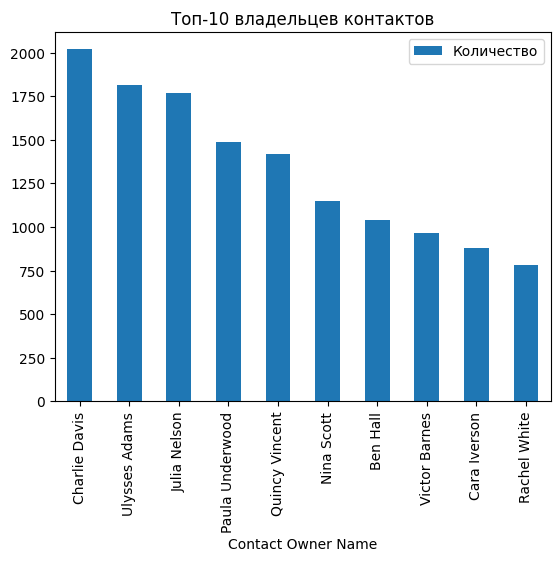

In [8]:
contact_owner_stats.head(10).plot(kind="bar", y="Количество", title="Топ-10 владельцев контактов")


датасет Calls

In [9]:
calls_df = pd.read_excel("Calls_f_clean.xlsx")

display(calls_df.head())

calls_df.info()

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Outgoing Call Status,Scheduled in CRM
0,5805028000000805001,2023-06-30 08:43:00,John Doe,NaN,Inbound,171.0,Received,NaN,NaN
1,5805028000000768006,2023-06-30 08:46:00,John Doe,NaN,Outbound,28.0,Attended Dialled,Completed,0.0
2,5805028000000764027,2023-06-30 08:59:00,John Doe,NaN,Outbound,24.0,Attended Dialled,Completed,0.0
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5.805028e+18,Outbound,6.0,Attended Dialled,Completed,0.0
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5.805028e+18,Outbound,11.0,Attended Dialled,Completed,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          95874 non-null  int64         
 1   Call Start Time             95874 non-null  datetime64[ns]
 2   Call Owner Name             95874 non-null  object        
 3   CONTACTID                   91941 non-null  float64       
 4   Call Type                   95874 non-null  object        
 5   Call Duration (in seconds)  95791 non-null  float64       
 6   Call Status                 95874 non-null  object        
 7   Outgoing Call Status        86875 non-null  object        
 8   Scheduled in CRM            86875 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 6.6+ MB


In [29]:
print("Всего строк:", len(calls_df))
print("Уникальных Id:", calls_df["Id"].nunique())
print("Дубликатов Id:", len(calls_df) - calls_df["Id"].nunique())
print("Пустых значений Id:", calls_df["Id"].isna().sum())


Всего строк: 95874
Уникальных Id: 95874
Дубликатов Id: 0
Пустых значений Id: 0


In [11]:
num_col = "Call Duration (in seconds)"

call_duration_stats = pd.DataFrame({
    "mean": [calls_df[num_col].mean()],
    "median": [calls_df[num_col].median()],
    "mode": [calls_df[num_col].mode().iloc[0]],
    "min": [calls_df[num_col].min()],
    "max": [calls_df[num_col].max()],
})

# Добавим диапазон
call_duration_stats["range"] = call_duration_stats["max"] - call_duration_stats["min"]

display(call_duration_stats)


,mean,median,mode,min,max,range
0,164.977263,8.0,0.0,0.0,7625.0,7625.0


In [12]:
cat_cols = ["Call Owner Name", "Call Type", "Call Status", "Outgoing Call Status"]

for col in cat_cols:
    print(f"\n📊 {col}")
    print("Пропусков:", calls_df[col].isna().sum())
    print("Уникальных значений:", calls_df[col].nunique())
    print(calls_df[col].value_counts(dropna=False).head(10))



📊 Call Owner Name
Пропусков: 0
Уникальных значений: 33
Call Owner Name
Yara Edwards     9059
Julia Nelson     7446
Ian Miller       7215
Charlie Davis    7213
Diana Evans      6857
Ulysses Adams    6085
Amy Green        5982
Nina Scott       5581
Victor Barnes    5439
Kevin Parker     5406
Name: count, dtype: int64

📊 Call Type
Пропусков: 0
Уникальных значений: 3
Call Type
Outbound    86875
Missed       5921
Inbound      3078
Name: count, dtype: int64

📊 Call Status
Пропусков: 0
Уникальных значений: 11
Call Status
Attended Dialled              70703
Unattended Dialled            16030
Missed                         5922
Received                       3077
Overdue                          60
Scheduled Attended Delay         22
Cancelled                        20
Scheduled Unattended Delay       17
Scheduled Attended               14
Scheduled Unattended              6
Name: count, dtype: int64

📊 Outgoing Call Status
Пропусков: 8999
Уникальных значений: 4
Outgoing Call Status
Completed

1- true, 0 - false

In [13]:
crm_counts = calls_df["Scheduled in CRM"].value_counts(dropna=False)
crm_percent = (crm_counts / len(calls_df) * 100).round(2)

pd.DataFrame({
    "Количество": crm_counts,
    "Доля, %": crm_percent
})


,Количество,"Доля, %"
Scheduled in CRM,,
0.0,86733,90.47
NaN,8999,9.39
1.0,142,0.15


<Axes: title={'center': 'Топ-10 владельцев звонков (Call Owner Name)'}, xlabel='Call Owner Name', ylabel='Количество звонков'>

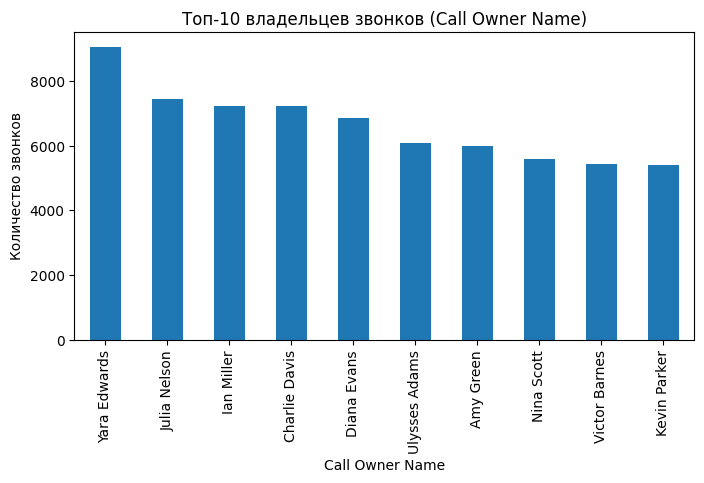

In [14]:
# 1️⃣ Распределение по Call Owner Name
calls_df["Call Owner Name"].value_counts().head(10).plot(
    kind="bar",
    title="Топ-10 владельцев звонков (Call Owner Name)",
    ylabel="Количество звонков",
    xlabel="Call Owner Name",
    figsize=(8,4)
)

<Axes: title={'center': 'Распределение по типам звонков (Call Type)'}, xlabel='Call Type', ylabel='Количество звонков'>

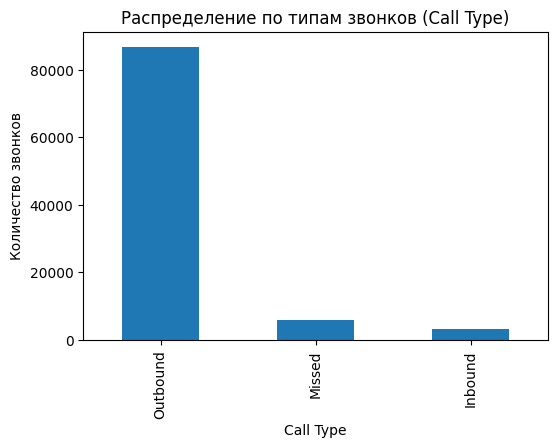

In [15]:
# 2️⃣ Распределение по Call Type
calls_df["Call Type"].value_counts().plot(
    kind="bar",
    title="Распределение по типам звонков (Call Type)",
    ylabel="Количество звонков",
    xlabel="Call Type",
    figsize=(6,4)
)

<Axes: title={'center': 'Распределение по статусам звонков (Call Status)'}, xlabel='Call Status', ylabel='Количество звонков'>

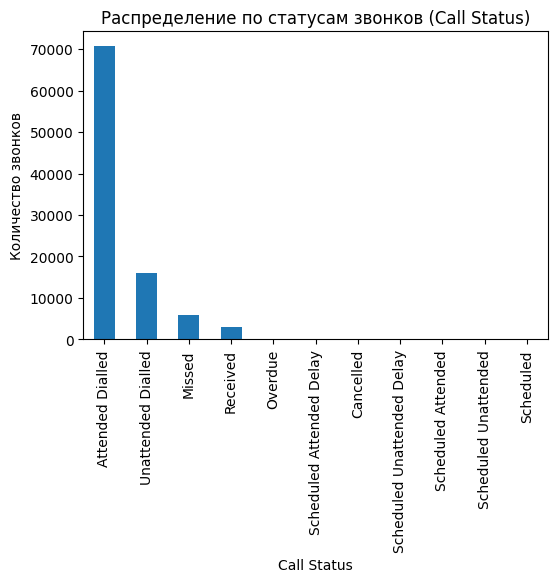

In [16]:
# 3️⃣ Распределение по Call Status
calls_df["Call Status"].value_counts().plot(
    kind="bar",
    title="Распределение по статусам звонков (Call Status)",
    ylabel="Количество звонков",
    xlabel="Call Status",
    figsize=(6,4)
)

датасет Deals

In [38]:
deals_df = pd.read_excel("Deals_f_clean0.xlsx", dtype={"Id": str,"Contact Name": str})

display(deals_df.head())

deals_df.info()

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,...,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_hours
0,5805028000056864695,Ben Hall,NaT,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,...,NaN,2024-06-21 15:30:00,NaN,NaN,NaN,NaN,5805028000056849495,NaN,NaN,NaN
1,5805028000056859489,Ulysses Adams,NaT,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,...,Morning,2024-06-21 15:23:00,6.0,NaN,0.0,2000.0,5805028000056834471,NaN,NaN,NaN
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,...,NaN,2024-06-21 14:45:00,NaN,NaN,NaN,NaN,5805028000056854421,NaN,NaN,0.4453
3,5805028000056824246,Eva Kent,2024-06-21,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,01:00:04,bloggersvideo14com,...,NaN,2024-06-21 13:32:00,NaN,NaN,NaN,NaN,5805028000056889351,NaN,NaN,1.0011
4,5805028000056873292,Ben Hall,2024-06-21,D - Non Target,Lost,Non target,/eng,discovery_DE,00:53:12,website,...,NaN,2024-06-21 13:21:00,NaN,NaN,NaN,NaN,5805028000056876176,NaN,NaN,0.8867


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19824 entries, 0 to 19823
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   19822 non-null  object        
 1   Deal Owner Name      19793 non-null  object        
 2   Closing Date         13136 non-null  datetime64[ns]
 3   Quality              17586 non-null  object        
 4   Stage                19822 non-null  object        
 5   Lost Reason          14353 non-null  object        
 6   Page                 19822 non-null  object        
 7   Campaign             15583 non-null  object        
 8   SLA                  14995 non-null  object        
 9   Content              13798 non-null  object        
 10  Term                 12101 non-null  object        
 11  Source               19822 non-null  object        
 12  Payment Type         483 non-null    object        
 13  Product              3537 non-n

In [39]:
print("Всего строк:", len(deals_df))
print("Уникальных Id:", deals_df["Id"].nunique())
print("Дубликатов Id:", len(deals_df) - deals_df["Id"].nunique())
print("Пустых значений Id:", deals_df["Id"].isna().sum())



Всего строк: 19824
Уникальных Id: 19822
Дубликатов Id: 2
Пустых значений Id: 2


In [40]:
deals_df = deals_df.dropna(subset=["Id"])


In [41]:
print("Всего строк:", len(deals_df))
print("Уникальных Id:", deals_df["Id"].nunique())
print("Дубликатов Id:", len(deals_df) - deals_df["Id"].nunique())
print("Пустых значений Id:", deals_df["Id"].isna().sum())


Всего строк: 19822
Уникальных Id: 19822
Дубликатов Id: 0
Пустых значений Id: 0


In [43]:
# Сохраняем очищенный датафрейм в новый Excel-файл
deals_df.to_excel("Deals_f_clean.xlsx", index=False)

print("✅ Файл успешно сохранён как 'Deals_f_clean.xlsx'")

✅ Файл успешно сохранён как 'Deals_f_clean.xlsx'


In [44]:
num_cols = ["SLA_hours", "Course duration", "Months of study", "Initial Amount Paid", "Offer Total Amount"]

# Рассчитаем среднее, медиану, моду, мин, макс
desc_stats = pd.DataFrame({
    "mean": deals_df[num_cols].mean(),
    "median": deals_df[num_cols].median(),
    "mode": deals_df[num_cols].mode().iloc[0],
    "min": deals_df[num_cols].min(),
    "max": deals_df[num_cols].max(),
})

# Диапазон (max - min)
desc_stats["range"] = desc_stats["max"] - desc_stats["min"]

display(desc_stats)


,mean,median,mode,min,max,range
SLA_hours,30.965165,5.4975,0.1697,0.0008,7474.5733,7474.5725
Course duration,10.197566,11.0000,11.0000,6.0000,11.0000,5.0000
Months of study,5.445107,5.0000,6.0000,0.0000,11.0000,11.0000
Initial Amount Paid,947.158754,1000.0000,1000.0000,0.0000,11500.0000,11500.0000
Offer Total Amount,7230.963054,11000.0000,11000.0000,0.0000,11500.0000,11500.0000


In [45]:
cat_cols = [
    "Deal Owner Name", "Quality", "Stage", "Lost Reason", "Page", "Campaign",
    "Content", "Term", "Source", "Payment Type", "Product", "Education Type",
    "City", "Level of Deutsch"
]

for col in cat_cols:
    print(f"\n📊 {col}")
    print("Пропусков:", deals_df[col].isna().sum())
    print("Уникальных значений:", deals_df[col].nunique())
    print(deals_df[col].value_counts(dropna=False).head(10))



📊 Deal Owner Name
Пропусков: 29
Уникальных значений: 27
Deal Owner Name
Charlie Davis      2799
Julia Nelson       2085
Ulysses Adams      2069
Quincy Vincent     1805
Paula Underwood    1771
Ben Hall           1303
Nina Scott         1218
Victor Barnes      1187
Cara Iverson       1033
Diana Evans         927
Name: count, dtype: int64

📊 Quality
Пропусков: 2236
Уникальных значений: 5
Quality
E - Non Qualified    6144
D - Non Target       6078
C - Low              3403
NaN                  2236
B - Medium           1543
A - High              418
Name: count, dtype: int64

📊 Stage
Пропусков: 0
Уникальных значений: 13
Stage
Lost                         13997
Call Delayed                  2243
Registered on Webinar         2070
Payment Done                   856
Waiting For Payment            324
Qualificated                   128
Registered on Offline Day       85
Need to Call - Sales            33
Need To Call                    31
Test Sent                       25
Name: count, dtype:

<Axes: title={'center': 'Топ-10 владельцев сделок'}, xlabel='Deal Owner Name', ylabel='Количество'>

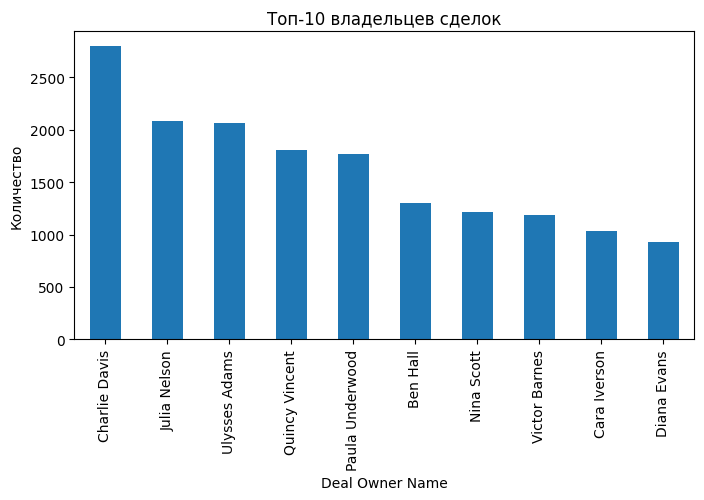

In [46]:
deals_df["Deal Owner Name"].value_counts().head(10).plot(
    kind="bar",
    title="Топ-10 владельцев сделок",
    ylabel="Количество",
    xlabel="Deal Owner Name",
    figsize=(8,4)
)


<Axes: title={'center': 'Топ-10 городов'}, xlabel='City', ylabel='Количество'>

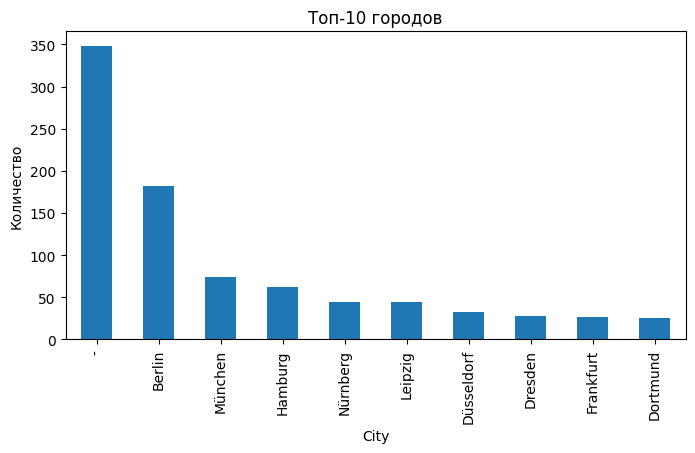

In [49]:
deals_df["City"].value_counts().head(10).plot(
    kind="bar",
    title="Топ-10 городов",
    ylabel="Количество",
    xlabel="City",
    figsize=(8,4)
)



<Axes: title={'center': 'Распределение по Stage'}, xlabel='Stage'>

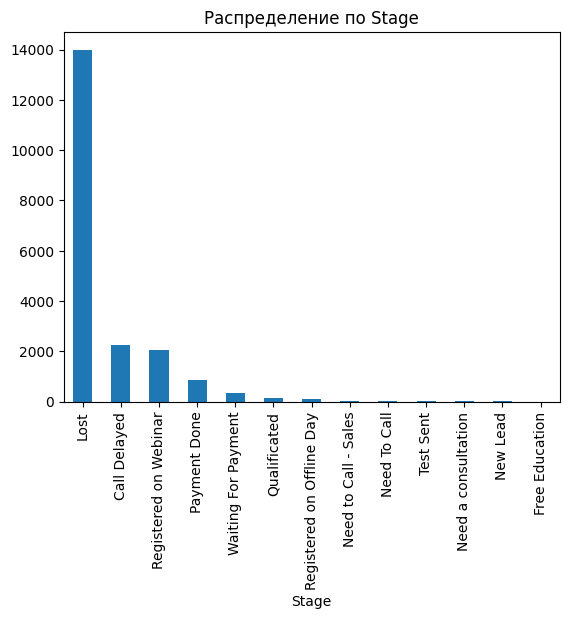

In [50]:
deals_df["Stage"].value_counts().plot(kind="bar", title="Распределение по Stage")

<Axes: title={'center': 'Распределение по Source'}, xlabel='Source'>

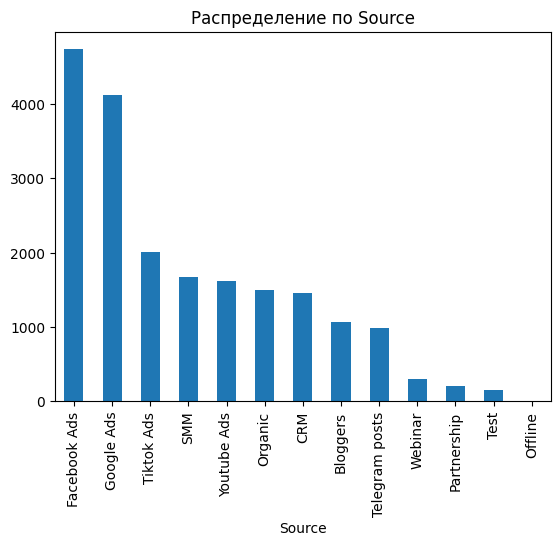

In [51]:

deals_df["Source"].value_counts().plot(kind="bar", title="Распределение по Source")

<Axes: title={'center': 'Распределение по Payment Type'}, xlabel='Payment Type'>

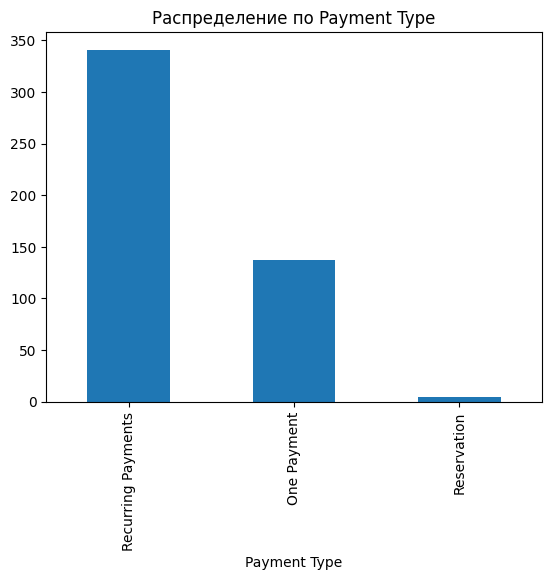

In [52]:

deals_df["Payment Type"].value_counts().plot(kind="bar", title="Распределение по Payment Type")

<Axes: title={'center': 'Распределение по Product'}, xlabel='Product'>

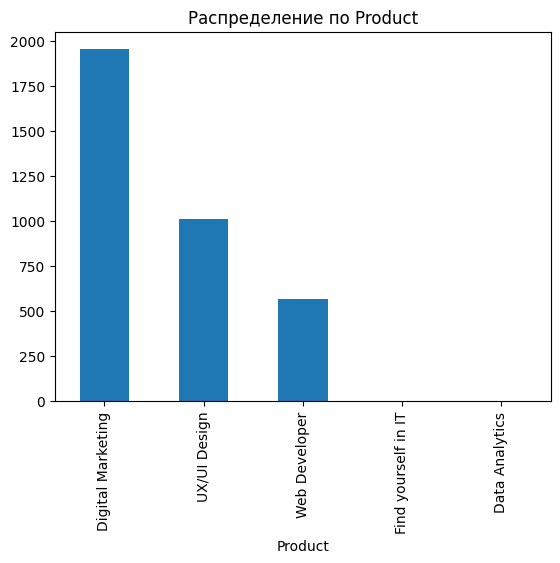

In [53]:

deals_df["Product"].value_counts().plot(kind="bar", title="Распределение по Product")

<Axes: title={'center': 'Распределение по Education Type'}, xlabel='Education Type'>

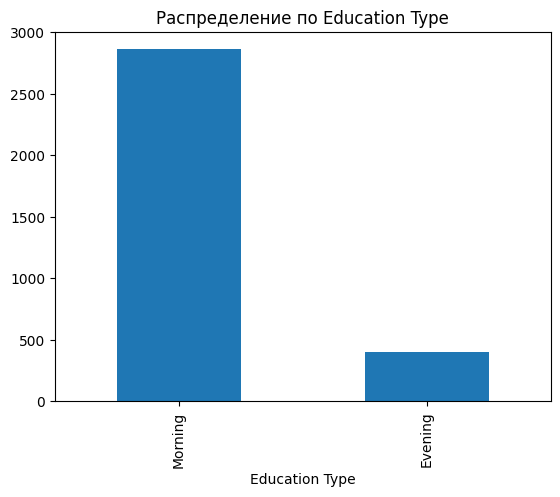

In [54]:
deals_df["Education Type"].value_counts().plot(kind="bar", title="Распределение по Education Type")